# Cart-pole: stabilizing an unstable equilibrium

The model is the declared cart-pole from [`models/cart_pole.py`](models/cart_pole.py):
an inverted pendulum on a cart, four states, one force input, starting from a
40-degree tilt. The upright target is an unstable equilibrium, the regime
where short-horizon NMPC visibly fails and terminal machinery earns its keep.
Two cases of the same model. Case 1 runs five sampling steps with the
infinite-horizon terminal segment (`drto.infinite_horizon`,
[Dinh et al. 2025](https://doi.org/10.1016/j.jprocont.2025.103565)) carrying
the tail, which deactivates the declared terminal cost since the tail owns
the cost-to-go. Case 2 runs fifty steps of plain finite horizon with the
terminal cost live. The pole is fast relative to the one-second sampling, so
both cases discretize with five collocation points per element.

## Case 1: five samples plus the infinite-horizon tail

In [1]:
import pyomo.environ as pyo
import drto
from models.cart_pole import cart_pole
from plotting import plot_states, plot_controls, plot_stage_cost

m1 = cart_pole(N=5)
pyo.TransformationFactory("dae.collocation").apply_to(m1, wrt=m1.t, nfe=5, ncp=5, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.infinite_horizon").apply_to(
    m1,
    nfe=3,                    # finite elements on the terminal segment
    ncp=5,                    # Gauss-Legendre points per element
    beta=1.2,                 # tail overestimation factor, > 1
    gamma="rule",             # the mesh rule, tanh(gamma*h) = tau_11; pass a number to override
    profile="collocation",    # segment control profile (pyomo-cvp)
)
pyo.TransformationFactory("drto.parameterize").apply_to(m1)  # the finite-horizon profiles
drto.build_objective(m1)
pyo.SolverFactory("pounce").solve(m1, tee=True)

pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmps9lt4shn.pyomo.sol


********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmps9lt4shn.pyomo.nl...
Parsed 377 vars, 

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 357, 'Number of variables': 377, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.8370416164398193}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [2]:
drto.info(m1)

horizon,"t (ContinuousSet, 26 points)"
states,"x (free), x_dot (free), theta (free), theta_dot (free)"
dynamics,dx[t] == x_dot[t] for t in t
dynamics,dx_dot[t] == (m_p*g*sin(theta[t])*cos(theta[t]) - (1 + kJ)*(F[t] + m_p*l*theta_dot[t]**2*sin(theta[t]) - b*x_dot[t]))/(m_p*cos(theta[t])**2 - (1 + kJ)*m_c) for t in t
dynamics,dtheta[t] == theta_dot[t] for t in t
dynamics,dtheta_dot[t] == (m_c*g*sin(theta[t]) - cos(theta[t])*(F[t] + m_p*l*theta_dot[t]**2*sin(theta[t])))/((1 + kJ)*m_c*l - m_p*l*cos(theta[t])**2) for t in t
controls,"F (piecewise_constant, free)"
tracking stage cost,cost[t] == (theta[t] - theta_ss)**2/theta_scale**2 + 0.01*(x[t] - x_ss)**2 + 0.01*(x_dot[t] - x_dot_ss)**2 + 0.01*(theta_dot[t] - theta_dot_ss)**2/theta_scale**2 + 0.1*(F[t] - F_ss)**2 for t in sorted(t)[:-1]
terminal cost,term == (theta[5] - theta_ss)**2/theta_scale**2 + 0.01*(x[5] - x_ss)**2 + 0.01*(x_dot[5] - x_dot_ss)**2 + 0.01*(theta_dot[5] - theta_dot_ss)**2/theta_scale**2
initial conditions,x[0] == x_hat
initial conditions,x_dot[0] == x_dot_hat


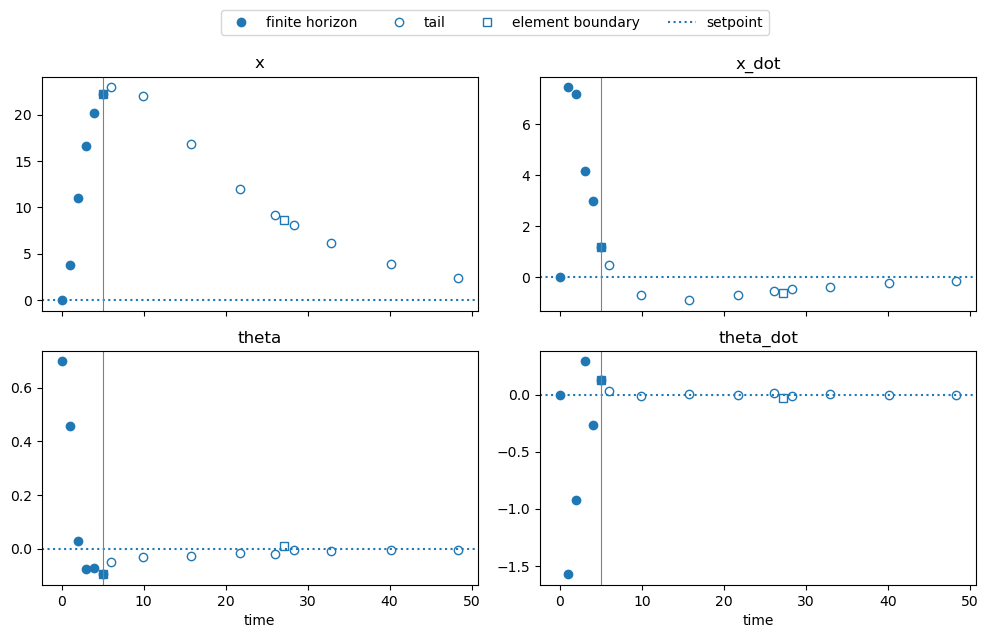

In [3]:
plot_states(m1);

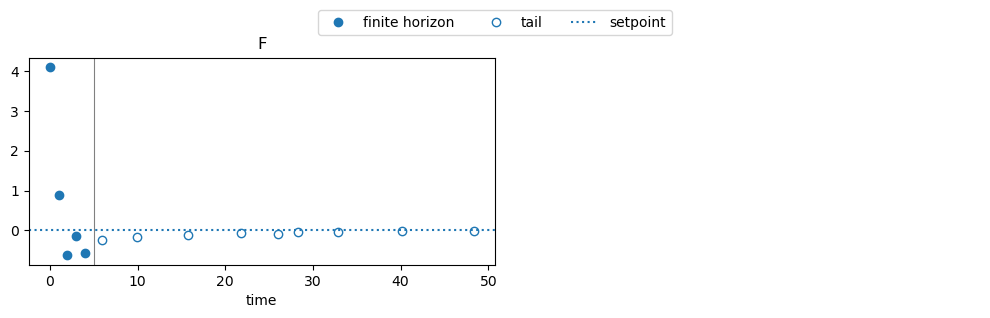

In [4]:
plot_controls(m1);

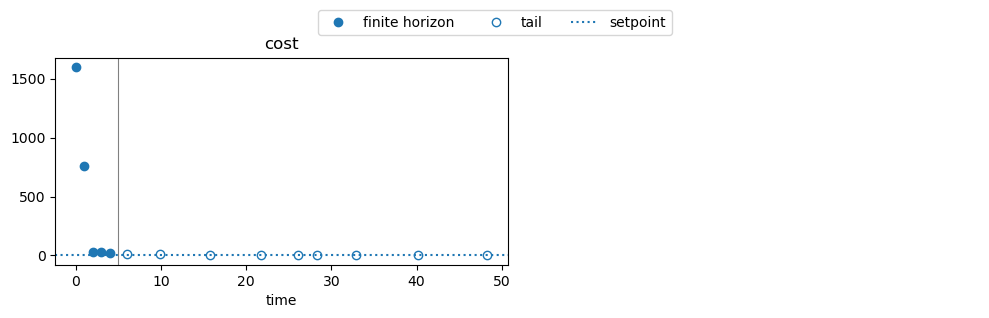

In [5]:
plot_stage_cost(m1);

## Case 2: fifty samples, finite horizon with the terminal cost

In [6]:
m2 = cart_pole(N=50)
pyo.TransformationFactory("dae.collocation").apply_to(m2, wrt=m2.t, nfe=50, ncp=5, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.parameterize").apply_to(m2)
drto.build_objective(m2)
pyo.SolverFactory("pounce").solve(m2, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpikel5f8q.pyomo.nl...
Parsed 2109 vars,

pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmpikel5f8q.pyomo.sol


  17  2.5893850e+03 1.14e-13 8.90e-13   -8.6 1.12e-06      - 1.00e+00 1.00e+00h  1


Number of Iterations....: 17

                                   (scaled)                 (unscaled)
Objective...............:   2.5893849586465190e+03    2.5893849586465190e+03
Dual infeasibility......:   8.9006232283053070e-13    8.9006232283053070e-13
Constraint violation....:   1.1368683772161603e-13    1.1368683772161603e-13
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5059503395178417e-09    2.5059503395178417e-09
Overall NLP error.......:   2.5059503395178417e-09    2.5059503395178417e-09


Number of objective function evaluations             = 19
Number of objective gradient evaluations             = 19
Number of equality constraint evaluations            = 19
Number of inequality constraint evaluations          = 19
Number of equality constraint Jacobian evaluations   = 19
Number of inequality constraint Jacobian evaluations = 19
Nu

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 2059, 'Number of variables': 2109, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.9477858543395996}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [7]:
drto.info(m2)

horizon,"t (ContinuousSet, 251 points)"
states,"x (free), x_dot (free), theta (free), theta_dot (free)"
dynamics,dx[t] == x_dot[t] for t in t
dynamics,dx_dot[t] == (m_p*g*sin(theta[t])*cos(theta[t]) - (1 + kJ)*(F[t] + m_p*l*theta_dot[t]**2*sin(theta[t]) - b*x_dot[t]))/(m_p*cos(theta[t])**2 - (1 + kJ)*m_c) for t in t
dynamics,dtheta[t] == theta_dot[t] for t in t
dynamics,dtheta_dot[t] == (m_c*g*sin(theta[t]) - cos(theta[t])*(F[t] + m_p*l*theta_dot[t]**2*sin(theta[t])))/((1 + kJ)*m_c*l - m_p*l*cos(theta[t])**2) for t in t
controls,"F (piecewise_constant, free)"
tracking stage cost,cost[t] == (theta[t] - theta_ss)**2/theta_scale**2 + 0.01*(x[t] - x_ss)**2 + 0.01*(x_dot[t] - x_dot_ss)**2 + 0.01*(theta_dot[t] - theta_dot_ss)**2/theta_scale**2 + 0.1*(F[t] - F_ss)**2 for t in sorted(t)[:-1]
terminal cost,term == (theta[50] - theta_ss)**2/theta_scale**2 + 0.01*(x[50] - x_ss)**2 + 0.01*(x_dot[50] - x_dot_ss)**2 + 0.01*(theta_dot[50] - theta_dot_ss)**2/theta_scale**2
initial conditions,x[0] == x_hat
initial conditions,x_dot[0] == x_dot_hat


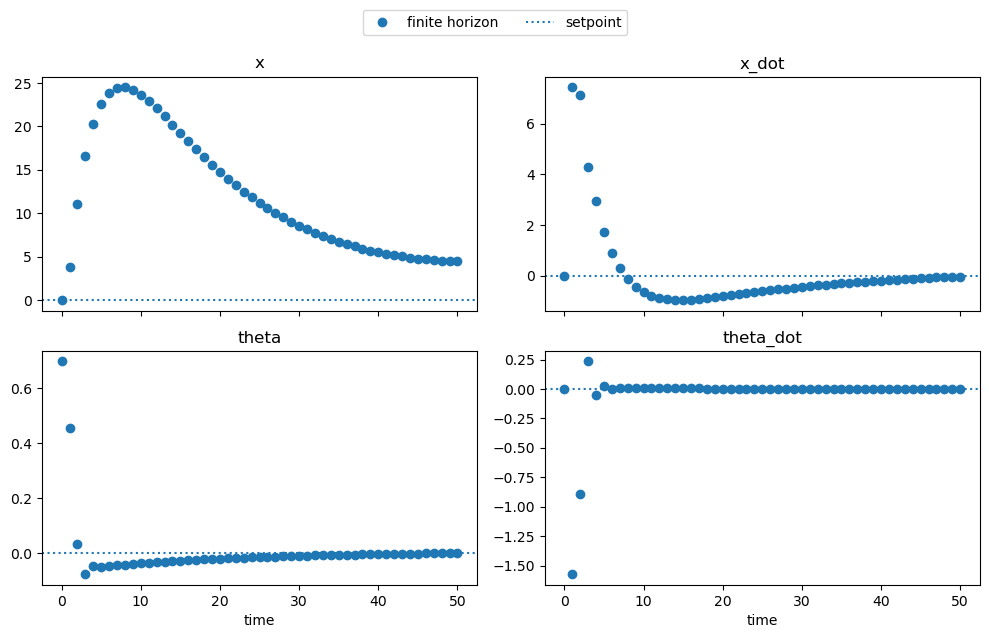

In [8]:
plot_states(m2);

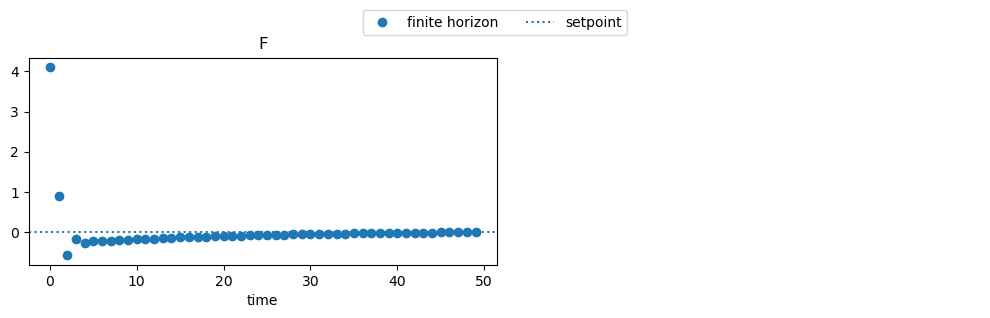

In [9]:
plot_controls(m2);

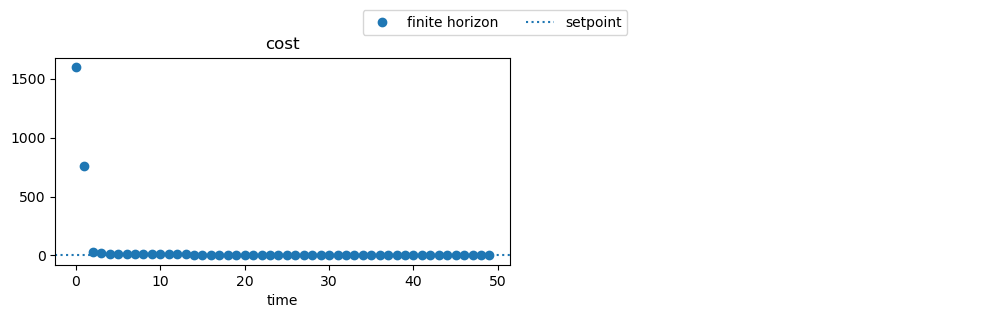

In [10]:
plot_stage_cost(m2);